# 01 · Data quality and exploratory analysis
### FinFast: repeat-loan propensity

**Goal of this notebook:** clean the 100K-row application file, document every data issue, and test whether *any* variable is related to `repeat_loan` before we build models.

**Outputs:** `data/processed/features.pkl` (used by notebooks 02 and 03) and figures `fig01`–`fig04`.

In [1]:
import sys, json, warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT))
warnings.filterwarnings("ignore")

from src.config import *
from src import plots as P
P.set_style()
pd.set_option("display.float_format", "{:,.4f}".format)
pd.set_option("display.max_columns", 30)

from src.cleaning import load_raw, clean
from src.features import build_features
from src import evaluation as E

## 1. Raw data at a glance

In [2]:
raw = load_raw()
print(f"{raw.shape[0]:,} rows × {raw.shape[1]} columns   |   unique customer_id: {raw.customer_id.nunique():,}")
print(f"Target repeat_loan: {raw.repeat_loan.mean():.1%} positive (moderately imbalanced)")
raw.head()

100,000 rows × 18 columns   |   unique customer_id: 60,363
Target repeat_loan: 30.1% positive (moderately imbalanced)


,customer_id,age,gender,city,income,employment_type,credit_score,loan_amount,approved_amount,application_date,registration_timestamp,nb_txn_cnt,days_since_last_txn_credit_repayment_24month,application_channel,loan_purpose,device_type,text_complaint,repeat_loan
0,C15796,30,Female,Delhi,35,Other,414.0000,59594,18152,08/07/24,15/06/21,28,74,Paid,Education,NaN,NaN,0
1,C861,32,Male,Delhi,107578,Other,618.0000,43717,17401,15/04/23,29/04/21,64,375,Referral,Medical,NaN,delay in update,0
2,C76821,25,NaN,Bengaluru,117556,Other,348.0000,12459,49637,19/02/22,24/12/22,9,259,Referral,Education,Other,app crash,0
3,C54887,40,Unknown,Hyderabad,135867,Salaried,881.0000,35569,36527,23/10/22,30/08/22,6,348,Organic,Education,Other,delay in update,0
4,C6266,18,Female,Chennai,131481,Salaried,840.0000,45459,57327,04/06/24,25/06/24,8,-16,Referral,Education,NaN,delay in update,1


In [3]:
summary = pd.DataFrame({
    "dtype": raw.dtypes.astype(str),
    "missing_%": raw.isna().mean() * 100,
    "unique": raw.nunique(),
    "example": raw.iloc[0],
})
summary.style.format({"missing_%": "{:.1f}"})

,dtype,missing_%,unique,example
customer_id,str,0.0,60363,C15796
age,int64,0.0,73,30
gender,str,25.1,3,Female
city,str,0.0,9,Delhi
income,int64,0.0,60482,35
employment_type,str,0.0,3,Other
credit_score,float64,14.9,600,414.000000
loan_amount,int64,0.0,46008,59594
approved_amount,int64,0.0,48348,18152
application_date,str,0.0,1095,08/07/24


In [4]:
raw.describe().T

,count,mean,std,min,25%,50%,75%,max
age,"100,000.0000",47.9639,21.0587,12.0000,30.0000,48.0000,66.0000,84.0000
income,"100,000.0000","66,020.8444","47,947.6788",10.0000,"23,432.0000","65,732.5000","107,827.2500","149,999.0000"
credit_score,"85,082.0000",599.6442,172.9408,300.0000,449.0000,600.0000,750.0000,899.0000
loan_amount,"100,000.0000","32,474.5288","15,898.4212","5,000.0000","18,757.7500","32,458.5000","46,290.2500","59,998.0000"
approved_amount,"100,000.0000","30,827.4781","16,874.4491","-4,986.0000","16,358.0000","30,888.5000","45,366.2500","59,999.0000"
nb_txn_cnt,"100,000.0000",24.8995,17.9494,0.0000,10.0000,21.0000,36.0000,144.0000
days_since_last_txn_credit_repayment_24month,"100,000.0000",225.7705,158.7218,-50.0000,88.0000,227.0000,363.0000,499.0000
repeat_loan,"100,000.0000",0.3007,0.4586,0.0000,0.0000,0.0000,1.0000,1.0000


## 2. Cleaning, with a log of every issue found

Each fix is counted and leaves a `flag_*` column behind. If messy data carries signal (for example, a thin-file customer with no credit score behaving differently), the model can still learn from it.

In [5]:
df, dq = clean(raw)
dq.style.format({"pct": "{:.1%}", "rows": "{:,}"}).hide(axis="index")

issue,rows,pct,action
customer_id appears on more than one row,"67,244",67.2%,Kept rows (applications); split train/test by customer to prevent leakage
same customer_id with different age,"66,719",66.7%,IDs are not reliable person keys - flagged as a data-lineage question
unparseable dates,0,0.0%,Parsed as DD/MM/YY
registration date after application date,"32,336",32.3%,Impossible ordering - flagged; tenure set to missing
gender blank or 'Unknown',"50,138",50.1%,Merged into 'Unknown'; gender excluded from model (fair lending)
city spelling variants (Bangalore/Bengaluru),"11,183",11.2%,Standardised to 'Bengaluru'
"income < 1,000 (reported in ₹ thousands)","19,957",20.0%,"Multiplied by 1,000; flagged"
age under 18 (not a legal borrower),"8,153",8.2%,Set to missing; flagged for source check
credit_score missing (thin-file / no-hit),"14,918",14.9%,Kept as missing (trees) / own WoE bin (scorecard); flagged
approved_amount negative,997,1.0%,Impossible value - set to missing; flagged


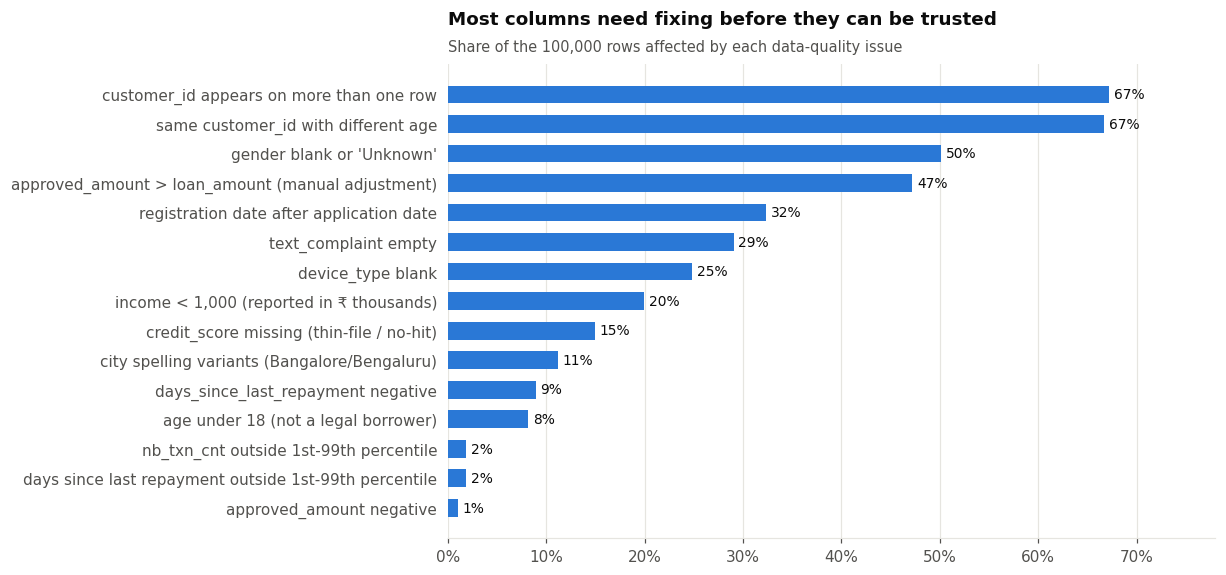

In [6]:
plot_dq = dq[dq.rows > 0].sort_values("pct")
labels = plot_dq.issue.str.replace("days_since_last_txn_credit_repayment_24month", "days since last repayment")
fig, ax = plt.subplots(figsize=(9, 5.6))
ax.barh(labels, plot_dq.pct, color=P.BLUE, height=0.6)
for i, v in enumerate(plot_dq.pct):
    ax.text(v + 0.005, i, f"{v:.0%}", va="center", fontsize=9)
P.pct_axis(ax, "x"); ax.grid(axis="x", color=P.GRID); ax.grid(axis="y", visible=False)
ax.set_xlim(0, 0.78)
ax.set_title("Most columns need fixing before they can be trusted", pad=26)
P.subtitle(ax, "Share of the 100,000 rows affected by each data-quality issue")
P.save(fig, "fig01_data_quality"); plt.show()

**Points to raise with the data owner** (they matter more than any model choice):

* **`customer_id` isn't a reliable person key.** 60K unique IDs over 100K rows, and the *same ID shows different ages*. We treat each row as an application and keep all rows of an ID in the same fold. We can't build a reliable customer-level history.
* **32% of rows have registration *after* application.** That's impossible. Either the timestamp means something else (e.g. KYC re-registration) or there's a pipeline join error.
* **47% of approvals exceed the amount applied for,** and about 1% are negative. Manual overrides need an audit trail; this is a governance flag.
* **20% of incomes are in thousands.** Rescaled, but the source form or API should enforce one unit.
* **8% of applicants are under 18.** They can't legally borrow, so this is a data-capture error or a KYC failure.

## 3. Feature engineering

In [7]:
f = build_features(df)
new_cols = ["tenure_days", "approval_ratio", "loan_to_income", "app_month", "prior_apps_same_id",
            "credit_band", "income_band", "ticket_band"]
f[new_cols].describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
tenure_days,"67,664.0000",NaN,NaN,NaN,527.6733,348.2445,0.0000,238.0000,479.0000,774.0000,"1,492.0000"
approval_ratio,"99,003.0000",NaN,NaN,NaN,1.4119,1.4805,0.0000,0.5176,0.9585,1.6809,11.8911
loan_to_income,"100,000.0000",NaN,NaN,NaN,0.6248,0.6165,0.0338,0.2455,0.4295,0.7587,5.9913
app_month,"100,000.0000",NaN,NaN,NaN,6.5121,3.4508,1.0000,4.0000,7.0000,10.0000,12.0000
prior_apps_same_id,"100,000.0000",NaN,NaN,NaN,0.5536,0.8084,0.0000,0.0000,0.0000,1.0000,7.0000
credit_band,100000,5,<600,42481,NaN,NaN,NaN,NaN,NaN,NaN,NaN
income_band,100000,3,Low,33483,NaN,NaN,NaN,NaN,NaN,NaN,NaN
ticket_band,99003,3,Small,33003,NaN,NaN,NaN,NaN,NaN,NaN,NaN


| Feature | Why it could matter for repeat borrowing |
|---|---|
| `tenure_days` | Longer relationship → more trust and familiarity with the app |
| `approval_ratio` | Got less than asked → unmet need → likely to return (or churn) |
| `loan_to_income` | Stretched borrowers may need a top-up |
| `app_month` | Seasonality (festive, school fees, travel) |
| `prior_apps_same_id` | Past behaviour predicts future behaviour (counts *earlier* applications only, no look-ahead) |
| `complaint_type`, `has_complaint` | Bad service experience → less likely to return |
| `flag_*` | Data-quality flags; missing credit score = thin-file customer |

## 4. Is anything related to repeat borrowing?

Before modelling, test every variable one at a time:

* **Information Value (IV):** the standard credit-scoring screen. Below 0.02 is "not predictive"; above 0.1 is useful.
* **Statistical tests:** point-biserial correlation for numbers, chi-square / Cramér's V for categories, with **Benjamini–Hochberg** correction because we run many tests at once.

In [8]:
uni = E.univariate_tests(f, NUMERIC_FEATURES + FLAG_FEATURES, CATEGORICAL_FEATURES + ["gender_clean"], TARGET)
uni.style.format({"effect": "{:+.4f}", "p_value": "{:.3f}", "p_adj_BH": "{:.3f}", "IV": "{:.5f}"}).hide(axis="index")

feature,type,test,effect,p_value,IV,p_adj_BH,IV_strength
nb_txn_cnt,numeric,point-biserial r,+0.0019,0.548,0.00083,0.927,Not predictive
approved_amount,numeric,point-biserial r,-0.0036,0.263,0.00074,0.621,Not predictive
approval_ratio,numeric,point-biserial r,-0.0004,0.910,0.00068,0.945,Not predictive
app_month,numeric,point-biserial r,+0.0044,0.163,0.00059,0.621,Not predictive
credit_score,numeric,point-biserial r,+0.0043,0.208,0.00049,0.621,Not predictive
city_clean,categorical,chi-square (Cramér's V),+0.0098,0.213,0.00046,0.621,Not predictive
loan_amount,numeric,point-biserial r,+0.0011,0.717,0.00043,0.927,Not predictive
age,numeric,point-biserial r,-0.0006,0.851,0.00041,0.945,Not predictive
loan_to_income,numeric,point-biserial r,+0.0009,0.767,0.00037,0.927,Not predictive
tenure_days,numeric,point-biserial r,+0.0042,0.273,0.00032,0.621,Not predictive


In [9]:
print(f"Highest IV of any feature: {uni.IV.max():.5f}  (threshold for 'weak' is 0.02, i.e. {0.02/uni.IV.max():.0f}x higher)")
print(f"Features significant after multiple-testing correction: {(uni.p_adj_BH < 0.05).sum()} of {len(uni)}")

Highest IV of any feature: 0.00083  (threshold for 'weak' is 0.02, i.e. 24x higher)
Features significant after multiple-testing correction: 0 of 27


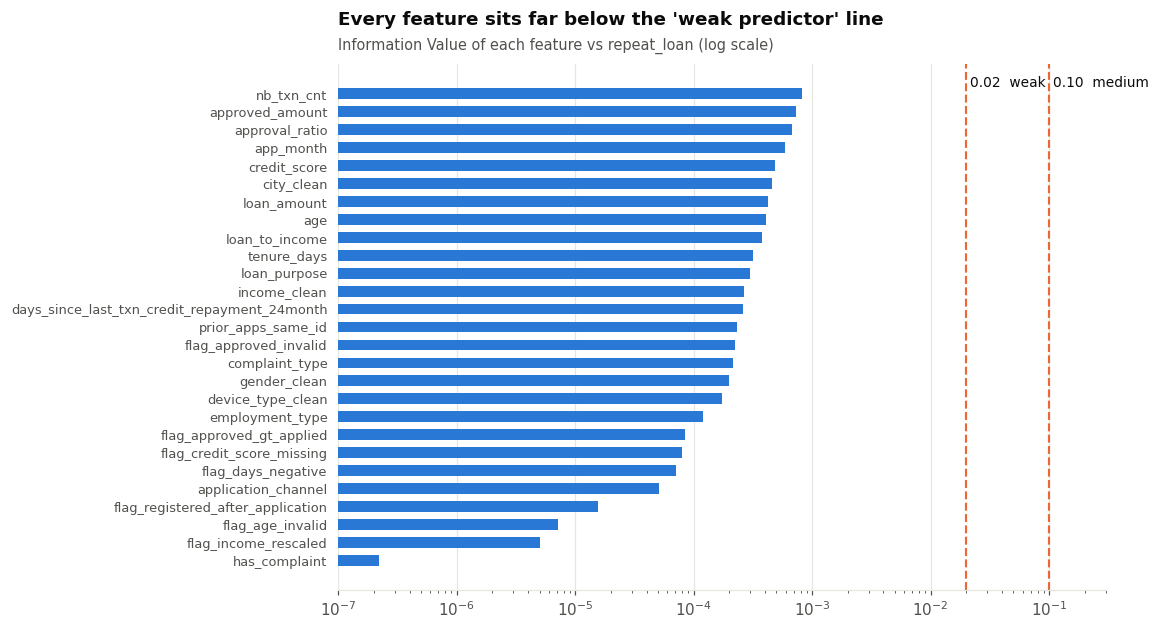

In [10]:
fig, ax = plt.subplots(figsize=(9, 6.2))
u = uni.sort_values("IV")
ax.barh(u.feature, u.IV, color=P.BLUE, height=0.6)
for thr, lab in [(0.02, "0.02  weak"), (0.1, "0.10  medium")]:
    ax.axvline(thr, color=P.ORANGE, lw=1.4, ls="--")
    ax.text(thr * 1.08, len(u) - 0.6, lab, color=P.INK, fontsize=9)
ax.set_xscale("log"); ax.set_xlim(1e-7, 0.3)
ax.grid(axis="x", color=P.GRID); ax.grid(axis="y", visible=False)
ax.tick_params(axis="y", labelsize=8.5)
ax.set_title("Every feature sits far below the 'weak predictor' line", pad=26)
P.subtitle(ax, "Information Value of each feature vs repeat_loan (log scale)")
P.save(fig, "fig03_information_value"); plt.show()

**The same story visually:** repeat rate across the range of each key variable. The grey band is where 95% of points would fall if the variable had no effect at all; with ~80 points, a few landing just outside it is expected by chance.

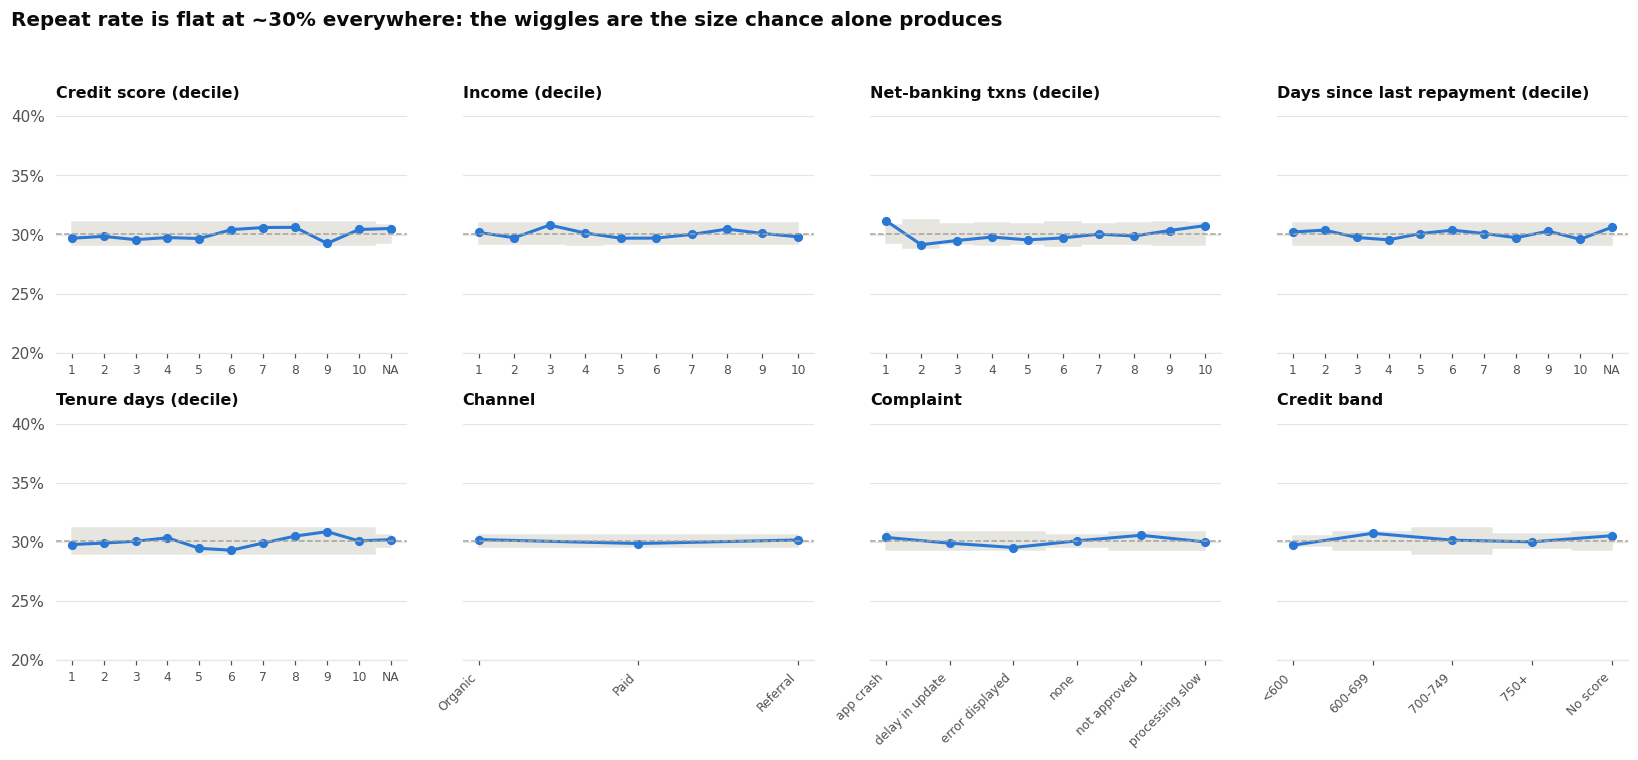

In [11]:
base = f[TARGET].mean()
panels = [("credit_score", "Credit score (decile)"), ("income_clean", "Income (decile)"),
          ("nb_txn_cnt", "Net-banking txns (decile)"), ("days_since_last_txn_credit_repayment_24month", "Days since last repayment (decile)"),
          ("tenure_days", "Tenure days (decile)"), ("application_channel", "Channel"),
          ("complaint_type", "Complaint"), ("credit_band", "Credit band")]
fig, axes = plt.subplots(2, 4, figsize=(15, 7), sharey=True)
for ax, (col, title) in zip(axes.flat, panels):
    s = f[col]
    if pd.api.types.is_numeric_dtype(s) and s.nunique() > 12:
        grp = (pd.qcut(s, 10, labels=False, duplicates="drop") + 1).fillna(99).astype(int)
        g = f.groupby(grp)[TARGET].agg(["mean", "size"]).sort_index()
        g.index = [("NA" if i == 99 else str(i)) for i in g.index]
    else:
        g = f.groupby(s, observed=True)[TARGET].agg(["mean", "size"])
        g.index = g.index.astype(str)
    x = np.arange(len(g))
    band = 1.96 * np.sqrt(base * (1 - base) / g["size"])
    ax.fill_between(x, base - band, base + band, color=P.GRID, step="mid", label="95% band if no effect")
    ax.plot(x, g["mean"], marker="o", color=P.BLUE, lw=2, ms=5)
    ax.axhline(base, color=P.GREY, lw=1, ls="--")
    ax.set_xticks(x, g.index, rotation=45 if not str(g.index[0]).isdigit() else 0, ha="right" if not str(g.index[0]).isdigit() else "center", fontsize=8)
    ax.set_title(title, fontsize=10.5, loc="left")
    ax.set_ylim(0.2, 0.4); P.pct_axis(ax)
fig.suptitle("Repeat rate is flat at ~30% everywhere: the wiggles are the size chance alone produces",
             x=0.01, ha="left", fontsize=13, fontweight="bold")
fig.tight_layout(rect=(0, 0, 1, 0.95))
P.save(fig, "fig02_repeat_rate_by_feature"); plt.show()

## 5. Does the label itself behave like a real 12-month repeat flag?

Two checks a credit team runs on any new target variable:

1. **Censoring:** a "took another loan within 12 months" flag needs 12 months of follow-up. The data ends in December 2024, so 2024 applications should have *fewer* recorded repeats.
2. **Internal consistency:** rows whose ID reappears with another application within 12 months should carry `repeat_loan = 1` more often.

In [12]:
audit = E.label_audit(f, TARGET, ID_COL)
print(f"Data ends {audit['data_end']:%d %b %Y}; {audit['share_without_full_12m_window']:.0%} of applications have <12 months of follow-up")
display(audit["by_year"].style.format({"mean": "{:.1%}", "size": "{:,}"}))
display(audit["by_reapply"].style.format({"mean": "{:.1%}", "size": "{:,}"}))

Data ends 30 Dec 2024; 33% of applications have <12 months of follow-up


,mean,size
application_date,,
2022,30.1%,"33,265"
2023,30.0%,"33,515"
2024,30.2%,"33,220"


,mean,size
id_reapplies_within_12m,,
No later application,30.1%,"60,363"
Re-applies after 12m,29.7%,"13,451"
Re-applies within 12m,30.3%,"26,186"


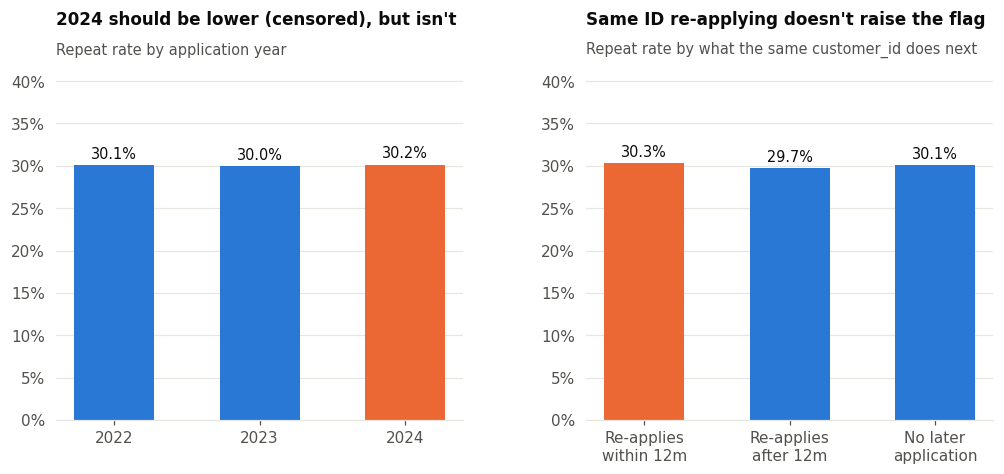

In [13]:
fig, (a1, a2) = plt.subplots(1, 2, figsize=(11, 4.2), gridspec_kw={"wspace": 0.3})
by = audit["by_year"]
a1.bar(by.index.astype(str), by["mean"], color=[P.BLUE, P.BLUE, P.ORANGE], width=0.55)
for i, v in enumerate(by["mean"]):
    a1.text(i, v + 0.008, f"{v:.1%}", ha="center", fontsize=9.5)
a1.set_ylim(0, 0.42); P.pct_axis(a1)
a1.set_title("2024 should be lower (censored), but isn't", pad=26, fontsize=11)
P.subtitle(a1, "Repeat rate by application year")
br = audit["by_reapply"].reindex(["Re-applies within 12m", "Re-applies after 12m", "No later application"])
a2.bar(["Re-applies\nwithin 12m", "Re-applies\nafter 12m", "No later\napplication"], br["mean"],
       color=[P.ORANGE, P.BLUE, P.BLUE], width=0.55)
for i, v in enumerate(br["mean"]):
    a2.text(i, v + 0.008, f"{v:.1%}", ha="center", fontsize=9.5)
a2.set_ylim(0, 0.42); P.pct_axis(a2)
a2.set_title("Same ID re-applying doesn't raise the flag", pad=26, fontsize=11)
P.subtitle(a2, "Repeat rate by what the same customer_id does next")
P.save(fig, "fig04_label_audit"); plt.show()

**What this means:** the label doesn't behave like a real outcome.

* 2024 applications show the same 30% repeat rate as 2022, even though none of them has had a full 12 months to repeat yet.
* IDs that *do* re-apply within 12 months are flagged as repeaters only 30% of the time, the same as everyone else.

Combined with the flat univariate results, the most likely explanation is that **`repeat_loan` was generated independently of the features** (common in synthetic case datasets). The other possibility is that it was joined to the wrong rows. Either way, this has to be raised before any model is trusted.

## 6. Save for modelling

In [14]:
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)
f.to_pickle(PROCESSED_DIR / "features.pkl")
dq.to_csv(PROCESSED_DIR / "data_quality_log.csv", index=False)
uni.to_csv(PROCESSED_DIR / "univariate_tests.csv", index=False)
print("saved", f.shape)

saved (100000, 41)


### Summary

| Finding | Implication |
|---|---|
| 14 data-quality issues, several affecting 20–50% of rows | Fixed and flagged; source-system fixes needed |
| Every feature has IV < 0.001 and no test is significant after correction | No single variable explains repeat borrowing |
| The label ignores censoring and the IDs' own re-application behaviour | The target likely carries no real signal; validate with the data owner |

Notebook 02 still builds the full modelling pipeline, because flat univariate results don't rule out *interactions*. It tests rigorously whether any model beats random.